# 个性化联邦学习算法对比分析 (Personalized FL Analysis)

本 Notebook 用于对比分析个性化联邦学习算法（如 FedRep, FedPer, FedALA 等）在相同实验配置下的性能表现。

In [1]:
import os
import sys
import torch
import matplotlib.pyplot as plt

# 添加项目根目录到路径
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from plot.utils import load_plot, load_plot_all_runs, ResultLoader

In [2]:
# --- 实验组定义 ---
experiments = {
    # 基准算法
    "Local": ("local", {}),

    # 层拆分类 (Layer-based)
    "FedPer": ("fedper", {}),
    "FedRep": ("fedrep", {"epochs_head": 5}),

    # 原型与知识蒸馏 (Proto & Distillation)
    "FedProto": ("fedproto", {"mu": 0.1}),
    "FedKD": ("fedkd", {"lr_g": 0.01, "energy": 0.9}),
    "FML": ("fml", {"alpha_fml": 1.0, "beta_fml": 1.0}),
    "FedTGP": ("fedtgp", {"lamda_": 10.0, "server_epochs": 10, "server_lr": 0.01, "margin_threshold": 1.0}),

    # 聚合优化类 (Aggregation-based)
    "FedALA": ("fedala", {"eta": 1.0, "rand_percent": 20, "layer_idx": 1, "ala_threshold": 0.1, "num_pre_loss": 10}),
    "FedSA": ("fedsa", {"alpha_sa": 0.9999, "lambda_r": 0.1, "lambda_mcl": 0.01, "lambda_cc": 1.0}),
    # 我们的方法 (Proposed)
    "FedDPC": ("feddpc", {"lamda_": 100.0, "lambda_p": 1.0, "lambda_acl": 0.01, "head_epochs": 10, "body_epochs": 1, "lr_head": 0.01, "lr_body": 0.01, "server_epochs": 100, "server_lr": 0.01})
}

# --- 通用参数 ---
common_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "alpha": 0.1,
    "num_clients": 10,
    "rounds": 200,
    "epochs": 10,
    "lr": 0.01,
    "batch_size": 64,
    "adj_type": "ring"
}

loader = ResultLoader(base_dir="../results_ray")

Figure saved to figures/test_accuracy_on_cifar10_dirichlet.png

Summary of ACC:
-----------------------------------------------------------------
Algorithm            |         Max Acc |     Last 10 Avg
-----------------------------------------------------------------
Local                |         83.4975 |         82.9064
FedPer               |         86.2239 |         86.1030
FedRep               |         86.1080 |         85.5784
FedProto-Model       |         84.1268 |         83.8985
FedProto-Proto       |         84.0241 |         83.8350
FedKD                |         85.4056 |         85.0068
FML-Model            |         84.8070 |         84.5085
FML-Global           |         66.5167 |         66.2258
FedTGP-Model         |         85.3570 |         82.8033
FedTGP-Proto         |         85.3509 |         82.3160
FedALA               |         87.8495 |         87.4567
FedSA                |         84.3261 |         84.2416
FedDPC-Model         |         86.2718 |       

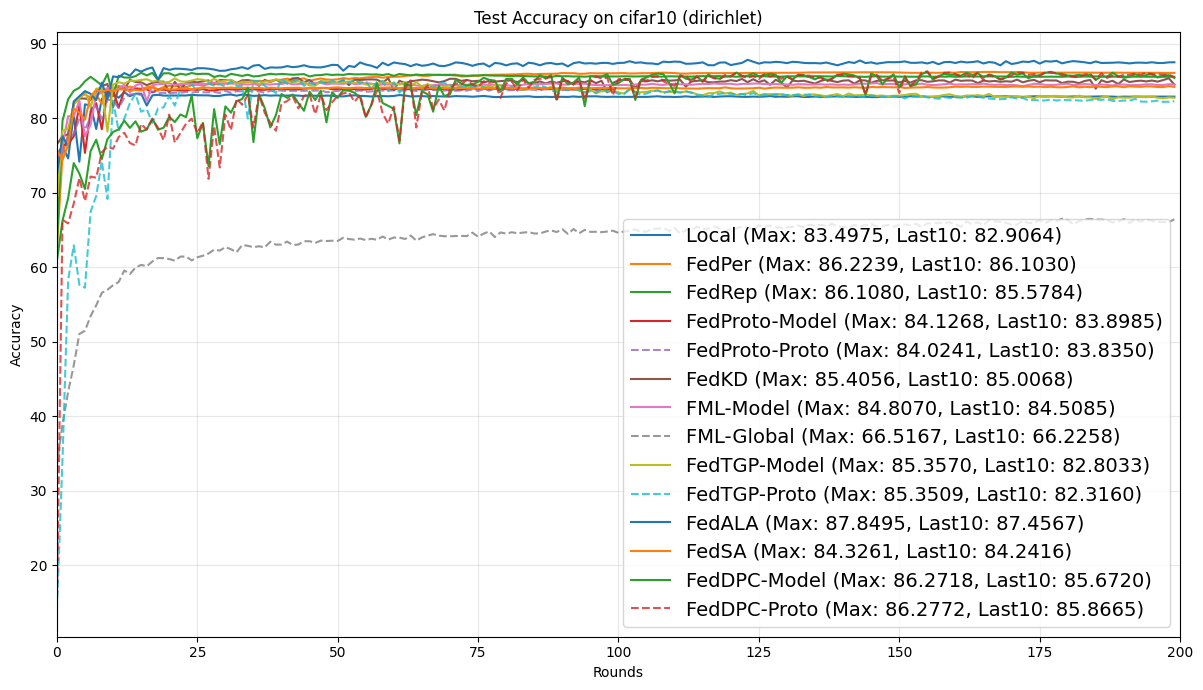

In [3]:
# 1. 加载并绘制曲线 (Run 0)
load_plot(
    selected_group=list(experiments.keys()),
    experiments=experiments,
    common_args=common_args,
    loader=loader,
    x_lim=200
)

In [5]:
# 2. 统计所有 Run 的平均性能
load_plot_all_runs(
    selected_group=list(experiments.keys()),
    experiments=experiments,
    common_args=common_args,
    loader=loader,
    x_lim=200
)


Summary of ALL RUNS (Mean ± Std):
---------------------------------------------------------------------------
Algorithm                 |              Max Acc |          Last 10 Avg
---------------------------------------------------------------------------
Local                     |  83.4975 ± 0.0000  |  82.9064 ± 0.0000  (1 runs)
FedPer                    |  86.1157 ± 0.0727  |  86.0047 ± 0.1098  (5 runs)
FedRep                    |  86.0744 ± 0.0783  |  85.4377 ± 0.0977  (5 runs)
FedProto-Model            |  84.0823 ± 0.0886  |  83.9406 ± 0.0993  (5 runs)
FedProto-Proto            |  84.0296 ± 0.0757  |  83.9098 ± 0.0973  (5 runs)
FedKD                     |  85.5377 ± 0.1004  |  84.8123 ± 0.2490  (5 runs)
FML-Model                 |  84.9849 ± 0.1825  |  84.6841 ± 0.1267  (5 runs)
FML-Global                |  66.4950 ± 0.0722  |  66.2042 ± 0.0589  (5 runs)
FedTGP-Model              |  85.3427 ± 0.0685  |  82.6402 ± 0.1979  (5 runs)
FedTGP-Proto              |  85.5126 ± 0.0908  |